<a href="https://colab.research.google.com/github/Ritika0919-sudo/heart_disease_prediction/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
#loading the csv data to the pandas datafram
heart_disease = pd.read_csv("/content/heart_disease_dataset.csv")

In [ ]:
#print first 10 rows of the dataset
heart_disease.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [ ]:
#print last 5 rows of the dataset
heart_disease.tail()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1
999,53,Male,226,116,82,Current,NaN,6,No,No,Yes,5,161,Yes,Asymptomatic,1


In [ ]:
#number of rowa ND COLUMN IN THE DTASET
heart_disease.shape

(1000, 16)

In [ ]:
#getting some info about the data
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [ ]:
heart_disease.isnull().sum()

,0
Age,0
Gender,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Smoking,0
Alcohol Intake,340
Exercise Hours,0
Family History,0
Diabetes,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

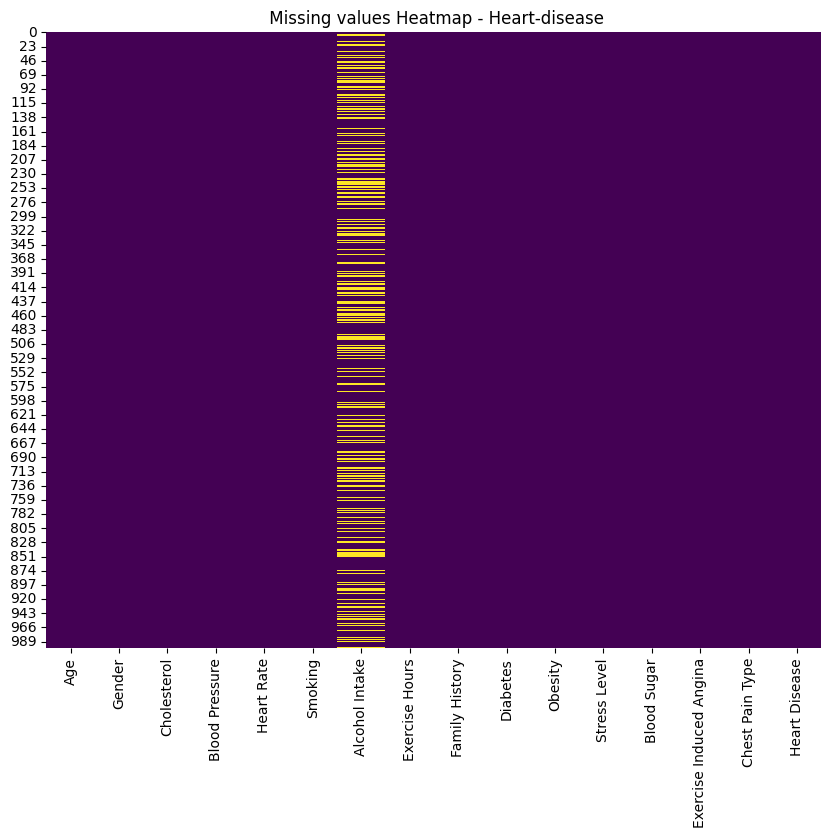

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(heart_disease.isnull(), cbar=False , cmap='viridis')
plt.title(" Missing values Heatmap - Heart-disease")
plt.show()

/tmp/ipython-input-1586444955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Alcohol Intake', data=heart_disease, palette='viridis')


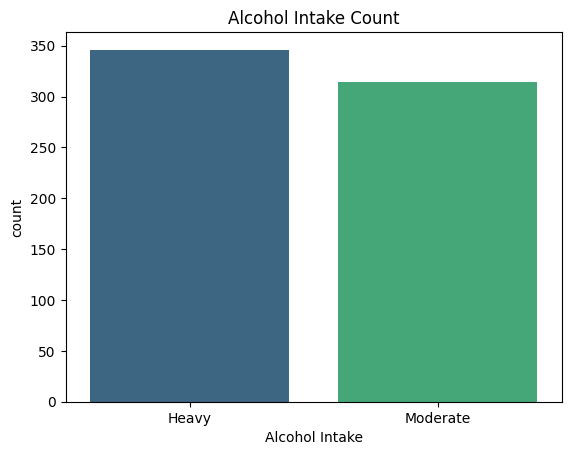

In [ ]:
sns.countplot(x='Alcohol Intake', data=heart_disease, palette='viridis')
plt.title("Alcohol Intake Count")
plt.show()


In [ ]:
heart_disease.fillna({'Alcohol Intake': heart_disease['Alcohol Intake'].mode()[0]}, inplace=True)


In [ ]:
heart_disease['Alcohol Intake'].isnull().sum()



np.int64(0)

In [ ]:
#STASTICAL MEASURE ABOUT THE DATA
heart_disease.describe()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52.293000,249.939000,135.2810,79.204000,4.529000,5.646000,134.941000,0.392000
std,15.727126,57.914673,26.3883,11.486092,2.934241,2.831024,36.699624,0.488441
min,25.000000,150.000000,90.0000,60.000000,0.000000,1.000000,70.000000,0.000000
25%,39.000000,200.000000,112.7500,70.000000,2.000000,3.000000,104.000000,0.000000
50%,52.000000,248.000000,136.0000,79.000000,4.500000,6.000000,135.000000,0.000000
75%,66.000000,299.000000,159.0000,89.000000,7.000000,8.000000,167.000000,1.000000
max,79.000000,349.000000,179.0000,99.000000,9.000000,10.000000,199.000000,1.000000


In [ ]:
#cgecking the distribution of target variable
heart_disease['Heart Disease'].value_counts()

,count
Heart Disease,
0,608
1,392


In [ ]:
#heart problem ---> 1
#no problem ==>0
#spliting the deatures and heart disease predection
x= heart_disease.drop(columns = 'Heart Disease' , axis=1)
y = heart_disease['Heart Disease']

print(x)

     Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0     75  Female          228             119          66  Current   
1     48    Male          204             165          62  Current   
2     53    Male          234              91          67    Never   
3     69  Female          192              90          72  Current   
4     62  Female          172             163          93    Never   
..   ...     ...          ...             ...         ...      ...   
995   56  Female          269             111          86    Never   
996   78  Female          334             145          76    Never   
997   79    Male          151             179          81    Never   
998   60  Female          326             151          68   Former   
999   53    Male          226             116          82  Current   

    Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0            Heavy               1             No       No     Yes   
1              NaN 

In [ ]:
print(y)

0      1
1      0
2      1
3      0
4      0
      ..
995    1
996    1
997    0
998    1
999    1
Name: Heart Disease, Length: 1000, dtype: int64


splittingbthe data in traning and test data

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y, test_size=0.3 , stratify = y, random_state=3 )

In [ ]:
print( x_train.shape , x_test.shape )

(700, 15) (300, 15)


model traning
logistic regression model


In [ ]:
model = LogisticRegression()

In [ ]:
heart_disease.dtypes


,0
Age,int64
Cholesterol,int64
Blood Pressure,int64
Heart Rate,int64
Exercise Hours,int64
Stress Level,int64
Blood Sugar,int64
Heart Disease,int64
Gender_Male,bool
Smoking_Former,bool


In [ ]:
heart_disease = pd.get_dummies(heart_disease, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Separate features (X) and target (y)
X = heart_disease.drop('Heart Disease', axis=1)
y = heart_disease['Heart Disease']

# Split into train/test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)


LogisticRegression(max_iter=5000)

In [ ]:
#accuracy
x_train_prediction = model.predict(x_train)
traning_data_accuracy = accuracy_score(x_train_prediction , y_train)

In [ ]:
print ('Accuracy om traning data:', traning_data_accuracy)

Accuracy om traning data: 0.87


In [ ]:
x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction , y_test)

In [ ]:
print ("Accuracy on test data :", test_data_accuracy)

Accuracy on test data : 0.87


predictive system


In [ ]:
# Example input data (replace with actual values for the individual)
# The order and meaning of the values must match the columns of the trained model (X).
# Refer to the columns of the X DataFrame to determine the correct order and encoding.
# You can get the column names using `X.columns`.

# Example structure of input_data_as_numpy_array based on the columns of the trained model (X)
# You'll need to determine the correct numerical values for the categorical features
# based on the one-hot encoding applied during training.

# For example, if 'Gender_Male' was a column in X, you would use 1 for Male and 0 for Female.
# Similarly for other one-hot encoded columns.

# *** Replace this example with your actual input data as a NumPy array ***
input_data_as_numpy_array = np.array([ 77, 309 , 110, 73 , 0 , 4 , 122 ,
                                      1, # Example for Gender_Male (assuming 1 for Male, 0 for Female)
                                      0, # Example for Smoking_Former
                                      1, # Example for Smoking_Never
                                      0, # Example for Alcohol Intake_Moderate
                                      0, # Example for Family History_Yes
                                      1, # Example for Diabetes_Yes
                                      1, # Example for Obesity_Yes
                                      1, # Example for Exercise Induced Angina_Yes
                                      0, # Example for Chest Pain Type_Atypical Angina
                                      0, # Example for Chest Pain Type_Non-anginal Pain
                                      0  # Example for Chest Pain Type_Typical Angina
                                     ])


#reshape the numpy array as we are predection for one daata point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

predection = model.predict(input_data_reshaped)
print(predection)

if (predection[0] == 0):
    print("The person does not have Heart Disease")
else:
    print("The person has Heart Disease")

[1]
The person has Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

# Example input
new_data = pd.DataFrame([{
    'Age': 45,
    'Cholesterol': 210,
    'Blood Pressure': 130,
    'Heart Rate': 85,
    'Exercise Hours': 2,
    'Stress Level': 5,
    'Blood Sugar': 110,
    'Gender_Male': True,
    'Smoking_Former': False,
    'Smoking_Never': True,
    'Alcohol Intake_Moderate': True,
    'Family History_Yes': True,
    'Diabetes_Yes': False,
    'Obesity_Yes': False,
    'Exercise Induced Angina_Yes': False,
    'Chest Pain Type_Atypical Angina': False,
    'Chest Pain Type_Non-anginal Pain': True,
    'Chest Pain Type_Typical Angina': False
}])

# Predict
prediction = model.predict(new_data)
if prediction[0] == 1:
    print("The person has Heart Disease")
else:
    print("The person does NOT have Heart Disease")

The person does NOT have Heart Disease


In [ ]:
import joblib

# Save the model
joblib.dump(model, "heart_disease_model.joblib")

['heart_disease_model.joblib']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib

# Save the model
joblib.dump(model, "heart_disease_model.joblib")

['heart_disease_model.joblib']

In [ ]:
import joblib

# Save the model to Google Drive
joblib.dump(model, "/content/drive/MyDrive/heart_disease_model.joblib")

['/content/drive/MyDrive/heart_disease_model.joblib']